In [1]:
import pandas as pd

df = pd.read_csv("../data/online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
df.shape

(1067371, 8)

In [1]:
import pandas as pd

df = pd.read_csv("../data/online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [3]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [4]:
df['Customer ID'].nunique()

5942

In [5]:
df = df.dropna(subset=['Customer ID'])

In [6]:
df.shape

(824364, 8)

In [8]:
df.duplicated().sum()

np.int64(26479)

In [9]:
df.duplicated().sum()

np.int64(26479)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(797885, 8)

In [12]:
df.dtypes

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
df.dtypes

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [15]:
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

In [16]:
df['Quantity'].min(), df['Quantity'].max()

(np.int64(-80995), np.int64(80995))

In [17]:
(df['Quantity'] < 0).sum()

np.int64(18390)

In [18]:
(df['Quantity'] > 0).sum()

np.int64(779495)

In [19]:
df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [20]:
df[df['Quantity'] < 0]['Invoice'].astype(str).str.startswith('C').value_counts()

Invoice
True    18390
Name: count, dtype: int64

In [21]:
df = df[df['Quantity'] > 0]

In [22]:
df.shape

(779495, 8)

In [23]:
df['Price'].min()

np.float64(0.0)

In [24]:
(df['Price'] == 0).sum()

np.int64(70)

In [25]:
df[df['Price'] == 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858.0,United Kingdom


In [26]:
df = df[df['Price'] > 0]

In [27]:
df.shape

(779425, 8)

In [28]:
df['Revenue'] = df['Quantity'] * df['Price']

In [29]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [30]:
df['Customer ID'] = df['Customer ID'].astype(int)

In [31]:
df.dtypes

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID             int64
Country                   str
Revenue               float64
dtype: object

In [32]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [33]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [34]:
customer_last_purchase = df.groupby('Customer ID')['InvoiceDate'].max()

customer_last_purchase.head()

Customer ID
12346   2011-01-18 10:01:00
12347   2011-12-07 15:52:00
12348   2011-09-25 13:13:00
12349   2011-11-21 09:51:00
12350   2011-02-02 16:01:00
Name: InvoiceDate, dtype: datetime64[us]

In [35]:
recency = (reference_date - customer_last_purchase).dt.days

recency.head()

Customer ID
12346    326
12347      2
12348     75
12349     19
12350    310
Name: InvoiceDate, dtype: int64

In [36]:
frequency = df.groupby('Customer ID')['Invoice'].nunique()

frequency.head()

Customer ID
12346    12
12347     8
12348     5
12349     4
12350     1
Name: Invoice, dtype: int64

In [37]:
monetary = df.groupby('Customer ID')['Revenue'].sum()

monetary.head()

Customer ID
12346    77556.46
12347     4921.53
12348     2019.40
12349     4428.69
12350      334.40
Name: Revenue, dtype: float64

In [38]:
rfm = pd.concat([recency, frequency, monetary], axis=1)

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [39]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [40]:
rfm['Monetary'].describe(percentiles=[0.90, 0.95, 0.99])

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
90%        5465.741000
95%        9374.227000
99%       29205.901000
max      580987.040000
Name: Monetary, dtype: float64

In [41]:
rfm['Frequency'].describe(percentiles=[0.90, 0.95, 0.99])

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
90%        13.000000
95%        21.000000
99%        46.000000
max       398.000000
Name: Frequency, dtype: float64

In [42]:
rfm[['Recency', 'Frequency', 'Monetary']].skew()

Recency       0.887198
Frequency    12.639951
Monetary     25.070190
dtype: float64

In [44]:
import numpy as np

In [45]:
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [46]:
rfm_log.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,5.789960,2.564949,11.258774
12347,1.098612,2.197225,8.501578
12348,4.330733,1.791759,7.611051
12349,2.995732,1.609438,8.396085
12350,5.739793,0.693147,5.815324


In [47]:
rfm_log[['Recency', 'Frequency', 'Monetary']].skew()

Recency     -0.488631
Frequency    1.001471
Monetary     0.269125
dtype: float64

In [49]:
pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 3.3 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.2 MB 3.8 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.2 MB 3.6 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.2 MB 4.0 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.2 MB 3.9 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.2 MB 4.2 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 4.2 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 4.4 MB/s eta 0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
 


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from sklearn.preprocessing import StandardScaler

In [51]:
scaler = StandardScaler()

In [52]:
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

In [53]:
from sklearn.cluster import KMeans

In [54]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

inertia

[8588.98534329588,
 6354.343153426074,
 4921.2333452738085,
 4099.10607877831,
 3554.696268860984,
 3194.500971551539,
 2902.433884952622,
 2656.5623279084407,
 2467.378466353908]

In [56]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 6.4 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.3 MB 6.3 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.3 MB 5.4 MB/s eta 0:00:02
   ------------------- -------------------- 4.5/9.3 MB 5.4 MB/s eta 0:00:01
   ---------------------- ----------------- 5.2/9.3 MB 5.0 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.3 MB 5.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 5.2 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 4.9 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------- ----------------------- 1.0/2.5 MB 4.9 MB


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
import matplotlib.pyplot as plt

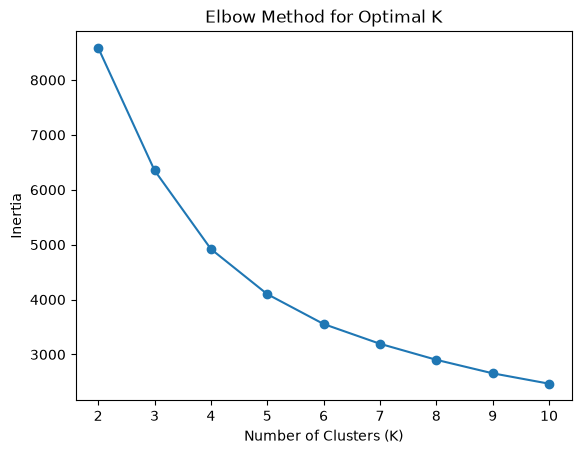

In [58]:
import matplotlib.pyplot as plt

k_values = range(2, 11)

plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [59]:
from sklearn.metrics import silhouette_score

In [60]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

silhouette_scores

[0.4386023012270002,
 0.3477454491034673,
 0.36497078400572347,
 0.3424961358761568,
 0.3347964327358149,
 0.30663604807644523,
 0.3033153691690236,
 0.29252387787540013,
 0.29052511584322954]

In [61]:
for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    
    print(f"K = {k}")
    print(pd.Series(labels).value_counts().sort_index())
    print()

K = 2
0    3558
1    2320
Name: count, dtype: int64

K = 3
0    2402
1    1216
2    2260
Name: count, dtype: int64

K = 4
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64

K = 5
0     458
1    1363
2    1294
3    1143
4    1620
Name: count, dtype: int64



In [62]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,18.06,32.90,20817.59
1,293.71,3.80,1385.85
2,48.87,9.13,3673.51
3,32.46,2.53,682.55
4,416.35,1.25,257.87


In [63]:
segment_names = {
    0: 'Champions',
    1: 'At-Risk Customers',
    2: 'Loyal Customers',
    3: 'New / Developing Customers',
    4: 'Dormant Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

In [64]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346,326,12,77556.46,2,Loyal Customers
12347,2,8,4921.53,2,Loyal Customers
12348,75,5,2019.40,2,Loyal Customers
12349,19,4,4428.69,2,Loyal Customers
12350,310,1,334.40,4,Dormant Customers


In [65]:
segment_summary = rfm.groupby('Segment').agg(
    Customers=('Monetary', 'size'),
    Total_Revenue=('Monetary', 'sum'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

segment_summary

,Customers,Total_Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,,
At-Risk Customers,1363,1888917.71,293.71,3.80,1385.85
Champions,458,9534456.88,18.06,32.90,20817.59
Dormant Customers,1620,417756.15,416.35,1.25,257.87
Loyal Customers,1294,4753522.54,48.87,9.13,3673.51
New / Developing Customers,1143,780150.98,32.46,2.53,682.55


In [66]:
segment_summary['Customer_%'] = (
    segment_summary['Customers'] / rfm.shape[0] * 100
).round(2)

segment_summary['Revenue_%'] = (
    segment_summary['Total_Revenue'] / rfm['Monetary'].sum() * 100
).round(2)

segment_summary

,Customers,Total_Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_%,Revenue_%
Segment,,,,,,,
At-Risk Customers,1363,1888917.71,293.71,3.80,1385.85,23.19,10.87
Champions,458,9534456.88,18.06,32.90,20817.59,7.79,54.88
Dormant Customers,1620,417756.15,416.35,1.25,257.87,27.56,2.40
Loyal Customers,1294,4753522.54,48.87,9.13,3673.51,22.01,27.36
New / Developing Customers,1143,780150.98,32.46,2.53,682.55,19.45,4.49


In [67]:
df['Purchase_Month'] = df['InvoiceDate'].dt.to_period('M')

In [68]:
df[['InvoiceDate', 'Purchase_Month']].head()

,InvoiceDate,Purchase_Month
0,2009-12-01 07:45:00,2009-12
1,2009-12-01 07:45:00,2009-12
2,2009-12-01 07:45:00,2009-12
3,2009-12-01 07:45:00,2009-12
4,2009-12-01 07:45:00,2009-12


In [69]:
customer_cohort = df.groupby('Customer ID')['Purchase_Month'].min()

customer_cohort.head()

Customer ID
12346    2009-12
12347    2010-10
12348    2010-09
12349    2010-04
12350    2011-02
Name: Purchase_Month, dtype: period[M]

In [70]:
df['Cohort_Month'] = df['Customer ID'].map(customer_cohort)

df[['Customer ID', 'Purchase_Month', 'Cohort_Month']].head()

,Customer ID,Purchase_Month,Cohort_Month
0,13085,2009-12,2009-12
1,13085,2009-12,2009-12
2,13085,2009-12,2009-12
3,13085,2009-12,2009-12
4,13085,2009-12,2009-12


In [71]:
df['Cohort_Index'] = (
    (df['Purchase_Month'].dt.year - df['Cohort_Month'].dt.year) * 12
    + (df['Purchase_Month'].dt.month - df['Cohort_Month'].dt.month)
)

df[['Customer ID', 'Purchase_Month', 'Cohort_Month', 'Cohort_Index']].head()

,Customer ID,Purchase_Month,Cohort_Month,Cohort_Index
0,13085,2009-12,2009-12,0
1,13085,2009-12,2009-12,0
2,13085,2009-12,2009-12,0
3,13085,2009-12,2009-12,0
4,13085,2009-12,2009-12,0


In [72]:
cohort_data = (
    df.groupby(['Cohort_Month', 'Cohort_Index'])['Customer ID']
      .nunique()
      .reset_index()
)

cohort_data.head(10)


,Cohort_Month,Cohort_Index,Customer ID
0,2009-12,0,955
1,2009-12,1,337
2,2009-12,2,319
3,2009-12,3,406
4,2009-12,4,363
5,2009-12,5,343
6,2009-12,6,360
7,2009-12,7,327
8,2009-12,8,321
9,2009-12,9,346


In [73]:
cohort_pivot = cohort_data.pivot(
    index='Cohort_Month',
    columns='Cohort_Index',
    values='Customer ID'
)

cohort_retention = cohort_pivot.divide(
    cohort_pivot[0],
    axis=0
) * 100

cohort_retention = cohort_retention.round(2)

cohort_retention

Cohort_Index,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Cohort_Month,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,...,30.26,26.28,30.26,28.27,25.97,25.55,31.52,30.47,40.73,19.69
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,...,15.14,23.50,19.84,18.54,19.58,24.28,19.32,24.54,5.74,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,...,20.05,16.04,16.31,14.44,22.99,22.99,16.31,5.88,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,10.84,...,16.93,17.38,15.58,17.61,20.09,21.22,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,10.54,10.88,...,15.65,13.95,14.97,18.03,22.45,5.78,NaN,NaN,NaN,NaN
2010-05,100.0,15.75,16.93,17.32,17.72,25.59,21.26,12.60,5.91,8.27,...,12.60,13.78,16.54,15.35,4.72,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.41,18.89,20.37,22.96,28.52,12.59,8.89,8.15,11.85,...,12.22,13.33,20.37,5.19,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.59,18.28,29.57,29.03,13.98,11.29,14.52,14.52,11.29,...,17.20,23.66,8.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.37,29.63,32.10,17.28,11.73,9.88,12.35,13.58,12.96,...,19.75,6.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


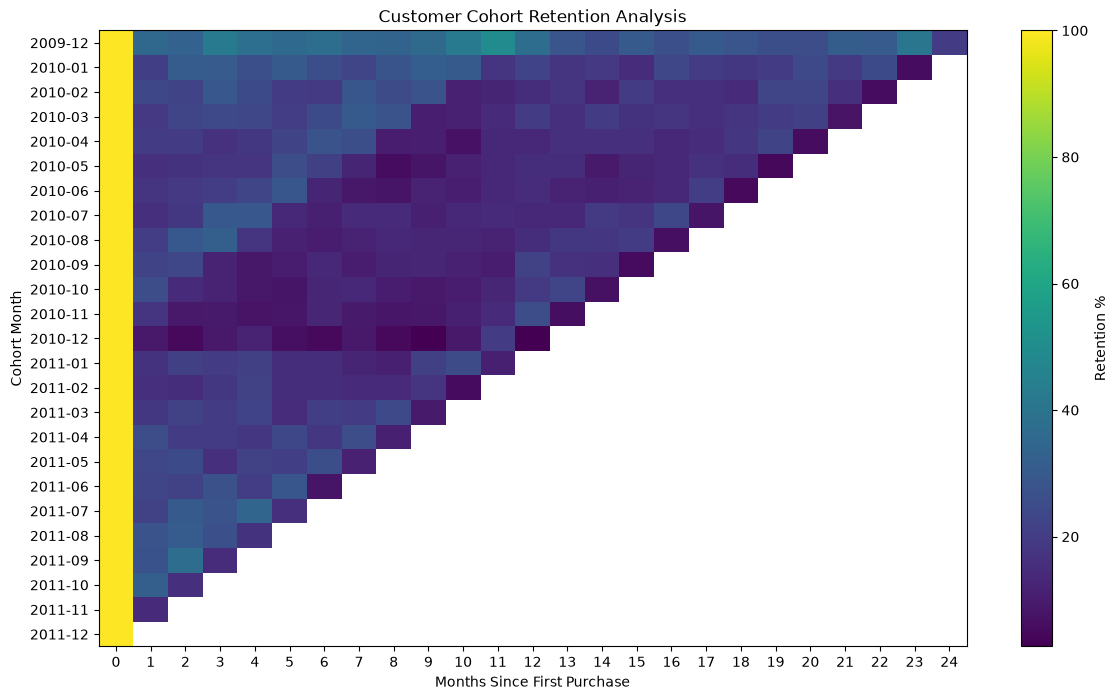

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

plt.imshow(
    cohort_retention,
    aspect='auto',
    interpolation='nearest'
)

plt.colorbar(label='Retention %')

plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.title('Customer Cohort Retention Analysis')

plt.xticks(range(len(cohort_retention.columns)), cohort_retention.columns)
plt.yticks(
    range(len(cohort_retention.index)),
    cohort_retention.index.astype(str)
)

plt.show()

In [75]:
customer_segments = rfm.reset_index()

customer_segments.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,12,77556.46,2,Loyal Customers
1,12347,2,8,4921.53,2,Loyal Customers
2,12348,75,5,2019.40,2,Loyal Customers
3,12349,19,4,4428.69,2,Loyal Customers
4,12350,310,1,334.40,4,Dormant Customers


In [76]:
customer_segments.to_csv(
    "../data/rfm_customer_segments.csv",
    index=False
)


In [77]:
cohort_retention.to_csv(
    "../data/cohort_retention.csv"
)

In [78]:
cohort_sizes = cohort_data[
    cohort_data['Cohort_Index'] == 0
][['Cohort_Month', 'Customer ID']].rename(
    columns={'Customer ID': 'Cohort_Size'}
)

cohort_tableau = cohort_data.merge(
    cohort_sizes,
    on='Cohort_Month',
    how='left'
)

cohort_tableau['Retention_%'] = (
    cohort_tableau['Customer ID'] /
    cohort_tableau['Cohort_Size'] * 100
).round(2)

cohort_tableau = cohort_tableau.rename(
    columns={'Customer ID': 'Customers'}
)

cohort_tableau.to_csv(
    "../data/cohort_retention_tableau.csv",
    index=False
)